# Posterior for E. coli local recombination rate and mutation rate using SBI

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from Bio import Phylo
import seaborn as sns
import torch
from torch.distributions import Uniform
import sbi
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.neural_nets import posterior_nn
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from discrete_uniform import DiscreteUniform
from LeaveLengthOut_NN import LeaveLengthOut_NN

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load bacillus gene data and clonal tree.

In [2]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/ecoli/ecoli_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

                                          ______________________________ 8
                                         |
  _______________________________________|          ____________________ 0
 |                                       |         |
 |                                       |         |                    , 21
 |                                       |_________|    ________________|
 |                                                 |   |                , 2
 |                                                 |   |                |
 |                                                 |___|                | 26
 |                                                     |
 |                                                     |   _____________ 7
 |                                                     |__|
 |                                                        |_____________ 10
 |
_|                                                                    __ 20
 |                           

In [3]:
x_obs_info_table = pd.read_csv("../data/ecoli/ecoli_block_info_updated.csv", index_col=0)
x_obs_info_table.head()

,Gene_Length,Start_pos,End_pos,Alignment,Gene_Length_raw,Start_pos_raw,End_pos_raw
Gene_ID,,,,,,,
0,1200,605790,606989,True,1200,605790,606989
1,1724,614003,615726,True,1731,614003,615733
2,4601,616186,620786,True,4602,616186,620787
3,6950,606990,613939,True,6956,606990,613945
4,3797,601974,605770,True,3800,601974,605773


In [4]:
drop_col = range(16, 32)

In [5]:
x_obs_df = pd.read_csv("../data/ecoli/ecoli_block_summary_stats.csv", header=None)
x_obs_np = x_obs_df.to_numpy()
x_obs_np = np.delete(x_obs_np, drop_col, axis=1)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([836, 30]), torch.float32)

### Delete observations with no signal

In [6]:
x_obs_info_table

,Gene_Length,Start_pos,End_pos,Alignment,Gene_Length_raw,Start_pos_raw,End_pos_raw
Gene_ID,,,,,,,
0,1200,605790,606989,True,1200,605790,606989
1,1724,614003,615726,True,1731,614003,615733
2,4601,616186,620786,True,4602,616186,620787
3,6950,606990,613939,True,6956,606990,613945
4,3797,601974,605770,True,3800,601974,605773
...,...,...,...,...,...,...,...
761_0,5476,1504811,1510286,True,5481,1504811,1510291
761_1,5475,1510287,1515761,True,5496,1510292,1515787
762,4170,1541972,1546141,True,4172,1541972,1546143


In [7]:
too_large_length = np.where(x_obs_info_table['Gene_Length'] > 10000)[0]
too_large_length

array([], dtype=int64)

In [8]:
no_signal_id = np.where(x_obs_np[:, 17] == 0)[0]
no_signal_id.shape, no_signal_id[:10]

((0,), array([], dtype=int64))

Ignore the observations that have too large gene length. But there is no observations with no signal.

## Load simulation data

In [9]:
theta1 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x1.csv', delimiter=",")
nrow1 = x1.shape[0]

theta2 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x2.csv', delimiter=",")
nrow2 = x2.shape[0]

theta3 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x3.csv', delimiter=",")
nrow3 = x3.shape[0]

theta4 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta4.csv', delimiter=",")
x4 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x4.csv', delimiter=",")
nrow4 = x4.shape[0]

theta5 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta5.csv', delimiter=",")
x5 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x5.csv', delimiter=",")
nrow5 = x5.shape[0]

theta6 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta6.csv', delimiter=",")
x6 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x6.csv', delimiter=",")
nrow6 = x6.shape[0]

theta7 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta7.csv', delimiter=",")
x7 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x7.csv', delimiter=",")
nrow7 = x7.shape[0]

theta8 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta8.csv', delimiter=",")
x8 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x8.csv', delimiter=",")
nrow8 = x8.shape[0]

theta9 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta9.csv', delimiter=",")
x9 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x9.csv', delimiter=",")
nrow9 = x9.shape[0]

theta10 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta10.csv', delimiter=",")
x10 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x10.csv', delimiter=",")
nrow10 = x10.shape[0]

x = np.vstack([x1, x2, x3, x4, x5, x6, x7, x8, x9, x10])
x = np.delete(x, drop_col, axis=1)
theta = np.vstack([theta1[:nrow1], theta2[:nrow2], theta3[:nrow3], theta4[:nrow4], theta5[:nrow5],
                   theta6[:nrow6], theta7[:nrow7], theta8[:nrow8], theta9[:nrow9], theta10[:nrow10]])

print(theta.shape, x.shape)

(57100, 3) (57100, 30)


In [10]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

### Find out-of-range observations

In [11]:
ignore_indices = []
no_segregation = []
out_stats = dict()
for i in range(x_obs_torch.shape[0]):
    ignore_i = False
    out_index = []
    for j in range(30):
        max_j = torch.max(x[:, j])
        min_j = torch.min(x[:, j])
        obs_j = x_obs_torch[i, j]
        if obs_j < min_j or obs_j > max_j:
            ignore_i = True
            out_index.append(j)
        if j == 17 and obs_j == 0:
            no_segregation.append(i)
    if ignore_i or torch.isnan(x_obs_torch[i, :]).any():
        print(f"Observation {i} is outside the range of simulated data.")
        ignore_indices.append(i)
        out_stats[i] = out_index

Observation 5 is outside the range of simulated data.
Observation 22 is outside the range of simulated data.
Observation 31 is outside the range of simulated data.
Observation 38 is outside the range of simulated data.
Observation 57 is outside the range of simulated data.
Observation 60 is outside the range of simulated data.
Observation 63 is outside the range of simulated data.
Observation 108 is outside the range of simulated data.
Observation 120 is outside the range of simulated data.
Observation 136 is outside the range of simulated data.
Observation 146 is outside the range of simulated data.
Observation 149 is outside the range of simulated data.
Observation 162 is outside the range of simulated data.
Observation 164 is outside the range of simulated data.
Observation 261 is outside the range of simulated data.
Observation 308 is outside the range of simulated data.
Observation 345 is outside the range of simulated data.
Observation 362 is outside the range of simulated data.


In [12]:
len(ignore_indices), len(no_segregation), len(out_stats)

(35, 0, 35)

In [13]:
out_index_all = []
for i in range(len(ignore_indices)):
    idx = ignore_indices[i]
    out_index_all += out_stats[idx]

In [14]:
from collections import Counter

integer_counts = Counter(out_index_all)

In [15]:
for i in range(30):
    print(f"Index {i}: {integer_counts[i]}")

Index 0: 0
Index 1: 0
Index 2: 0
Index 3: 0
Index 4: 0
Index 5: 0
Index 6: 0
Index 7: 0
Index 8: 11
Index 9: 5
Index 10: 0
Index 11: 0
Index 12: 15
Index 13: 6
Index 14: 0
Index 15: 0
Index 16: 0
Index 17: 0
Index 18: 0
Index 19: 0
Index 20: 0
Index 21: 0
Index 22: 35
Index 23: 21
Index 24: 0
Index 25: 14
Index 26: 0
Index 27: 0
Index 28: 0
Index 29: 0


## NPE

### Create prior to pass range knowledge to NPE

In [16]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.2]))
prior_theta = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([100.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_theta, prior_L],
    validate_args=False,
    device=torch_device
)

### Using all simulations

In [17]:
embedding_net = LeaveLengthOut_NN(
    input_dim=30,
    num_hiddens=128,
    num_hidden_layers=1,
    num_outputs=2)
neural_posterior = posterior_nn(
    model="nsf",
    embedding_net=embedding_net,
    hidden_features=30,
    num_transforms=8,
    num_bins=5,
    z_score_theta="independent",
    z_score_x="independent"
)

In [18]:
seed = 100
num_posterior_samples=1000

inference = NPE_C(density_estimator=neural_posterior, device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [19]:
# density_estimator = inference.append_simulations(theta, x).train(
#     max_num_epochs=500,
#     training_batch_size=100,
#     learning_rate=0.0001,
#     stop_after_epochs=20,
#     clip_max_norm=None
# )
# posterior = inference.build_posterior(density_estimator)

In [20]:
# fig, axes = plot_summary(
#     inference, 
#     tags=["training_loss", "validation_loss"], 
#     figsize=(8, 4)
# )
# plt.title("Training and Validation Loss")
# plt.show()

### Save the trained NPE

In [21]:
save_path = "../data/ecoli/trained_npe_posterior.pt"

# torch.save(
#     {
#         "posterior": posterior,
#         "sbi_version": sbi.__version__,
#         "seed": seed,
#         "learning_rate": 0.0001,
#         "max_num_epochs": 500,
#     },
#     save_path,
# )

In [22]:
checkpoint = torch.load(save_path, map_location="cpu")
posterior = checkpoint["posterior"]

C:\Users\u2008181\AppData\Local\Temp\ipykernel_17776\1569981112.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path, map_location="cpu")


### Plug in observation data to get posterior

In [23]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
theta_post.shape

(836, 1000, 3)

In [24]:
for i in range(x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue

    theta_post_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                        show_progress_bars=False, reject_outside_prior=True)
    theta_post[i, :, :] = theta_post_torch.cpu().detach().numpy()

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  outputs, _ = torch.triangular_solve(


### Plot bar plots by position

In [25]:
x_obs_info_table

,Gene_Length,Start_pos,End_pos,Alignment,Gene_Length_raw,Start_pos_raw,End_pos_raw
Gene_ID,,,,,,,
0,1200,605790,606989,True,1200,605790,606989
1,1724,614003,615726,True,1731,614003,615733
2,4601,616186,620786,True,4602,616186,620787
3,6950,606990,613939,True,6956,606990,613945
4,3797,601974,605770,True,3800,601974,605773
...,...,...,...,...,...,...,...
761_0,5476,1504811,1510286,True,5481,1504811,1510291
761_1,5475,1510287,1515761,True,5496,1510292,1515787
762,4170,1541972,1546141,True,4172,1541972,1546143


In [26]:
x_obs_info_table['End_pos_raw'].max()

np.int64(4938906)

In [27]:
from hotspot_DoG import DoGHotspotDetector

In [28]:
gene_starts = np.delete(x_obs_info_table['Start_pos_raw'].values, no_signal_id)
gene_ends = np.delete(x_obs_info_table['End_pos_raw'].values, no_signal_id)
ord_start_pos = np.argsort(gene_starts)
ord_end_pos = np.argsort(gene_ends)
print(np.all(ord_start_pos == ord_end_pos))

True


Detected hotspot segments:
  1.84-2.07 Mb; 22 genes; peak P=1.000; peak enrichment=7.57x
  2.79-2.91 Mb; 20 genes; peak P=1.000; peak enrichment=4.61x


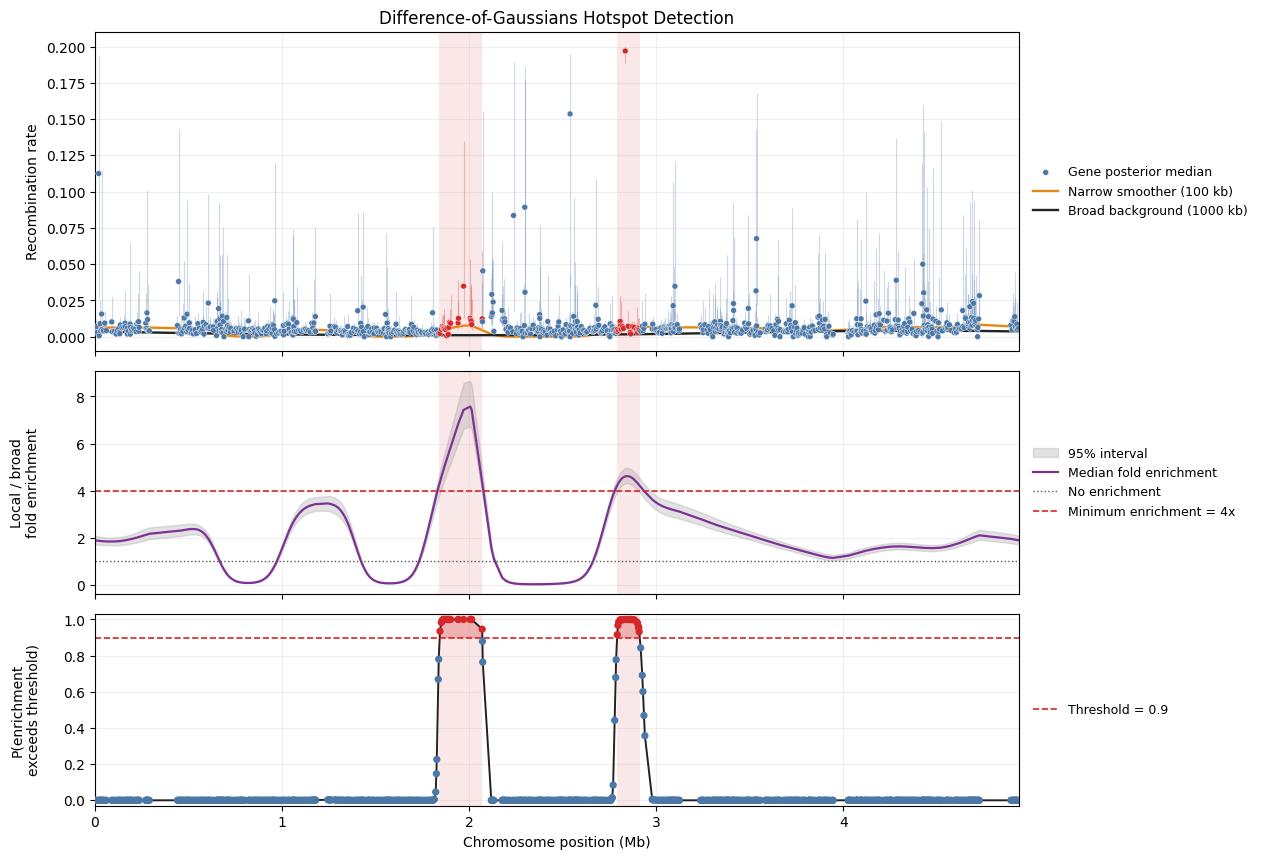

In [30]:
positions = gene_starts[ord_start_pos]
posterior_draws = theta_post[ord_start_pos, :, 0].transpose()
indices_below_zero = np.where(posterior_draws <= 0)
posterior_draws[indices_below_zero] = np.finfo(np.float64).eps

detector = DoGHotspotDetector(
    narrow_bandwidth_bp=100_000,
    broad_bandwidth_bp=1_000_000,
    min_fold_enrichment=4,
    probability_threshold=0.90,
    residual_log_sd=0.20,
    min_effective_genes=1.0,
    random_state=10,
    chromosome_length_bp=4938906
)
result = detector.fit(positions, posterior_draws)

print("Detected hotspot segments:")
for segment in result.segments(max_gap_bp=800_000):
    print(
        f"  {segment['start_position_bp'] / 1e6:.2f}-"
        f"{segment['end_position_bp'] / 1e6:.2f} Mb; "
        f"{segment['n_genes']} genes; "
        f"peak P={segment['peak_probability']:.3f}; "
        f"peak enrichment={segment['peak_fold_enrichment']:.2f}x"
    )

result.plot(
    rate_label="Recombination rate",
    save_path="../output/ecoli_local_recomb_dog.pdf"
)
plt.show()

In [31]:
recomb_hotspots = pd.DataFrame(index=range(len(result.segments(max_gap_bp=800_000))),
                               columns=['start_position_bp',
                                        'end_position_bp',
                                        'n_genes',
                                        'peak_probability',
                                        'peak_fold_enrichment'])
recomb_hotspots

,start_position_bp,end_position_bp,n_genes,peak_probability,peak_fold_enrichment
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN


In [32]:
positions_end = gene_ends[ord_start_pos]
for i in range(len(result.segments(max_gap_bp=800_000))):
    segment = result.segments(max_gap_bp=800_000)[i]
    pos_start_index = segment['start_index']
    pos_end_index = segment['end_index']
    recomb_hotspots.loc[i, 'start_position_bp'] = positions[pos_start_index]
    recomb_hotspots.loc[i, 'end_position_bp'] = positions_end[pos_end_index]
    recomb_hotspots.loc[i, 'n_genes'] = segment['n_genes']
    recomb_hotspots.loc[i, 'peak_probability'] = segment['peak_probability']
    recomb_hotspots.loc[i, 'peak_fold_enrichment'] = segment['peak_fold_enrichment']

recomb_hotspots

,start_position_bp,end_position_bp,n_genes,peak_probability,peak_fold_enrichment
0,1844174,2071008,22,1.0,7.571493
1,2791496,2916774,20,1.0,4.613001


Detected hotspot segments:
  1.84-2.07 Mb; 24 genes; peak P=1.000; peak enrichment=342.92x
  4.68-4.73 Mb; 19 genes; peak P=1.000; peak enrichment=342.88x


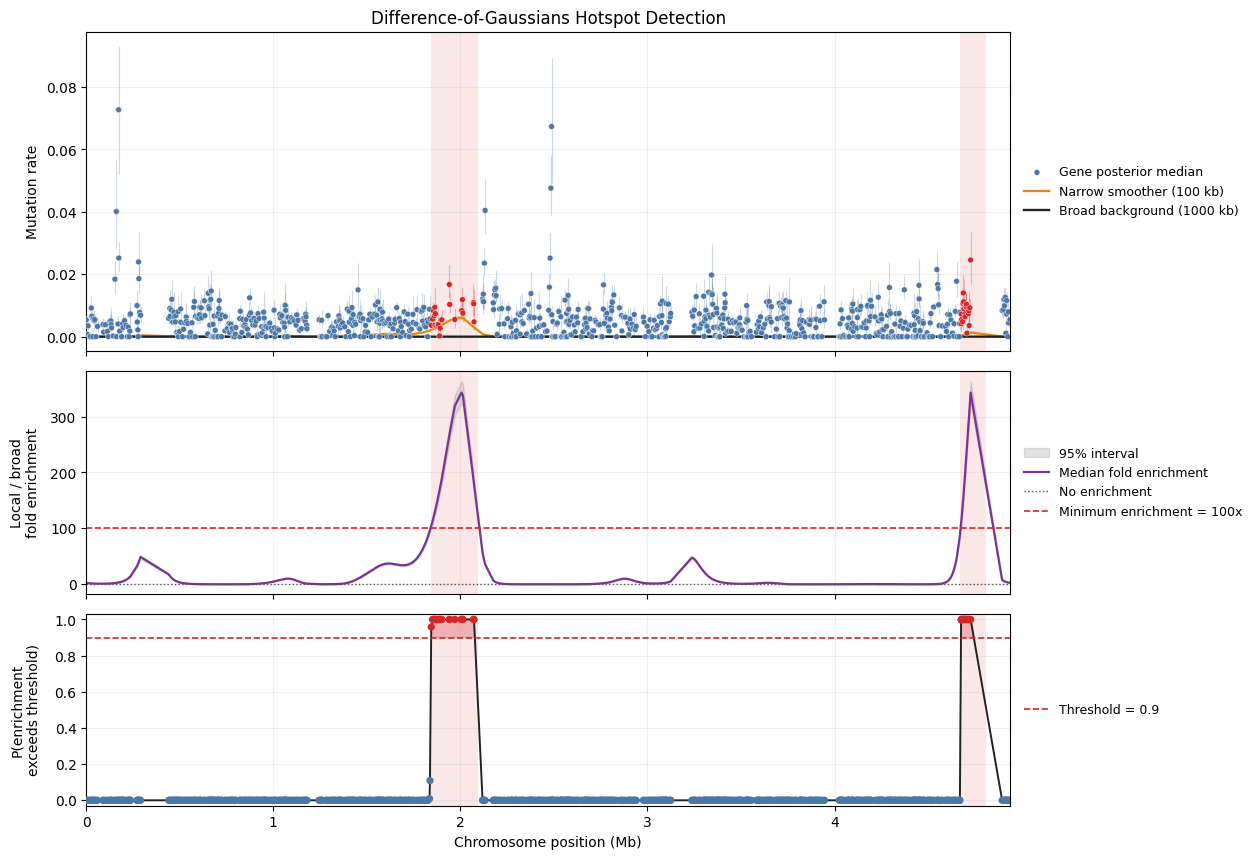

In [39]:
positions = gene_starts[ord_start_pos]
posterior_draws = theta_post[ord_start_pos, :, 1].transpose()
indices_below_zero = np.where(posterior_draws <= 0)
posterior_draws[indices_below_zero] = np.finfo(np.float64).eps

detector = DoGHotspotDetector(
    narrow_bandwidth_bp=100_000,
    broad_bandwidth_bp=1_000_000,
    min_fold_enrichment=100.0,
    probability_threshold=0.90,
    residual_log_sd=0.20,
    min_effective_genes=1.0,
    random_state=10,
    chromosome_length_bp=4938906
)
result = detector.fit(positions, posterior_draws)

print("Detected hotspot segments:")
for segment in result.segments(max_gap_bp=800_000):
    print(
        f"  {segment['start_position_bp'] / 1e6:.2f}-"
        f"{segment['end_position_bp'] / 1e6:.2f} Mb; "
        f"{segment['n_genes']} genes; "
        f"peak P={segment['peak_probability']:.3f}; "
        f"peak enrichment={segment['peak_fold_enrichment']:.2f}x"
    )

result.plot(
    rate_label="Mutation rate",
    save_path="../output/ecoli_local_mutate_dog.pdf"
)
plt.show()

In [40]:
mutate_hotspots = pd.DataFrame(index=range(len(result.segments(max_gap_bp=800_000))),
                               columns=['start_position_bp',
                                        'end_position_bp',
                                        'n_genes',
                                        'peak_probability',
                                        'peak_fold_enrichment'])
mutate_hotspots

,start_position_bp,end_position_bp,n_genes,peak_probability,peak_fold_enrichment
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN


In [41]:
positions_end = gene_ends[ord_start_pos]
for i in range(len(result.segments(max_gap_bp=800_000))):
    segment = result.segments(max_gap_bp=800_000)[i]
    pos_start_index = segment['start_index']
    pos_end_index = segment['end_index']
    mutate_hotspots.loc[i, 'start_position_bp'] = positions[pos_start_index]
    mutate_hotspots.loc[i, 'end_position_bp'] = positions_end[pos_end_index]
    mutate_hotspots.loc[i, 'n_genes'] = segment['n_genes']
    mutate_hotspots.loc[i, 'peak_probability'] = segment['peak_probability']
    mutate_hotspots.loc[i, 'peak_fold_enrichment'] = segment['peak_fold_enrichment']

mutate_hotspots

,start_position_bp,end_position_bp,n_genes,peak_probability,peak_fold_enrichment
0,1844174,2073314,24,1.0,342.922282
1,4676291,4728841,19,1.0,342.878822


In [42]:
with pd.ExcelWriter('../output/ecoli_hotspots.xlsx') as writer:
    recomb_hotspots.to_excel(writer, sheet_name='Recombination', index=False)
    mutate_hotspots.to_excel(writer, sheet_name='Mutation', index=False)